In [4]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

df = pd.read_csv(
    "amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["text", "label"]
)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_end = int(0.7 * len(df))
val_end   = int(0.85 * len(df))

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train, y_train = train["text"], train["label"]
X_val,   y_val   = val["text"],   val["label"]
X_test,  y_test  = test["text"],  test["label"]

In [46]:
def create_datasets(model, max_tokens, max_len, batch_size, loss, optimizer):
    y_tr = y_train
    y_v = y_val
    y_te = y_test
    if loss == "hinge":
        y_tr = y_tr.map(lambda x: 1 if x == 1 else -1)
        y_v = y_v.map(lambda x: 1 if x == 1 else -1)
        y_te = y_te.map(lambda x: 1 if x == 1 else -1)
    vectorize = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=max_len
    )

    vectorize.adapt(X_train.values)
    
    def make_ds(texts, labels):
        ds = tf.data.Dataset.from_tensor_slices((texts, labels))
        ds = ds.batch(batch_size).map(lambda x, y: (vectorize(x), y))
        return ds.prefetch(tf.data.AUTOTUNE)
        
    train_ds = make_ds(X_train.values, y_tr.values)
    val_ds   = make_ds(X_val.values,   y_v.values)
    test_ds  = make_ds(X_test.values,  y_te.values)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )
    
    model.summary()
    return train_ds, val_ds, test_ds

In [40]:
def use_model(name, epochs, model, train_ds, val_ds, test_ds):
    folder = "images/"
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )
    model.summary()
    test_loss, test_acc = model.evaluate(test_ds)
    print("Test accuracy:", test_acc)
    print("Test loss:", test_loss)
    history_dict = history.history
    
    loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, "bo-", label="Training loss")
    plt.plot(epochs, val_loss, "ro-", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(folder + name + "_loss.png", dpi=150)   # uloží obrázek
    plt.show()

    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, "bo-", label="Training accuracy")
    plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(folder + name + "_accuracy.png", dpi=150)
    plt.show()

    return test_loss, test_acc

In [44]:
import time

model_data = []
default_activation="relu"

def run(
    name,
    optimizer="adam",
    activation=default_activation,
    loss="binary_crossentropy",
    main_layers=[layers.GlobalAveragePooling1D()],
    extra_layers=None,
    max_tokens=10000,
    max_len=40,
    epochs=10,
    batch_size=32
):
    if extra_layers is None:
        extra_layers = [layers.Dense(64, activation=activation)]
    start = time.time()  
    print(f"-> Model {name}")
    model = keras.Sequential([
        layers.Embedding(input_dim=max_tokens, output_dim=64, input_length=max_len)
    ] + main_layers + extra_layers + [
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    train_ds, val_ds, test_ds = create_datasets(model, max_tokens=max_tokens, max_len=max_len, batch_size=batch_size, loss=loss, optimizer=optimizer)
    loss, acc = use_model(name, epochs, model, train_ds, val_ds, test_ds)
    end = time.time()
    took = end - start
    print(f"<- Model {name} took {took}ms")
    model_data.append({"name": name, "time": took, "loss": loss, "acc": acc})
    # 3 empty lines to separate models
    for _ in range(3):
        print()

-> Model default


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7429 - loss: 0.5660
Test accuracy: 0.7599999904632568
Test loss: 0.5596940517425537


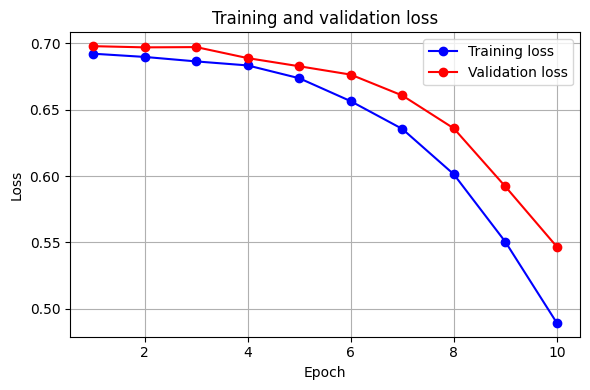

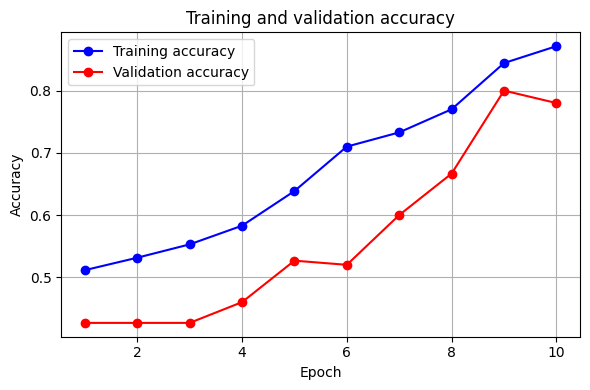

<- Model default took 7.760937452316284ms



-> Model 5-epochs


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_26 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4577 - loss: 0.6829
Test accuracy: 0.47333332896232605
Test loss: 0.6803271770477295


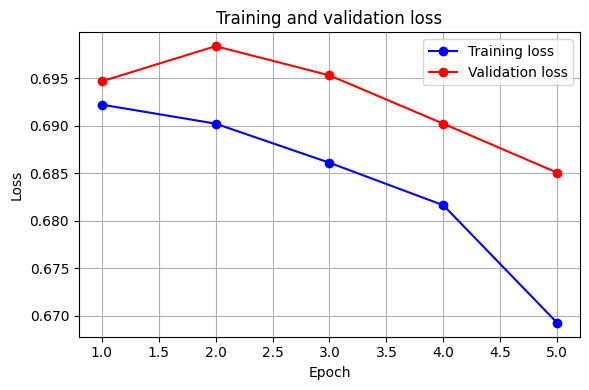

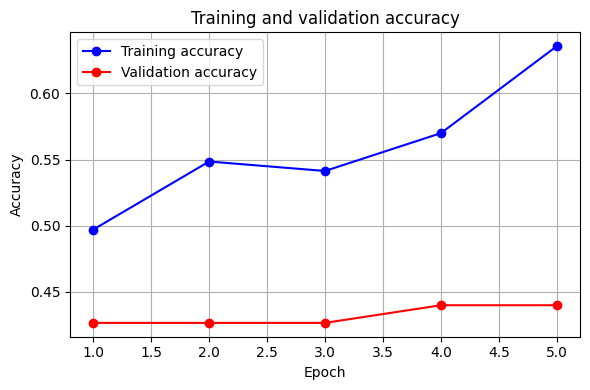

<- Model 5-epochs took 5.5725202560424805ms



-> Model 20-epochs


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_27 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7564 - loss: 0.4418
Test accuracy: 0.7599999904632568
Test loss: 0.4386991262435913


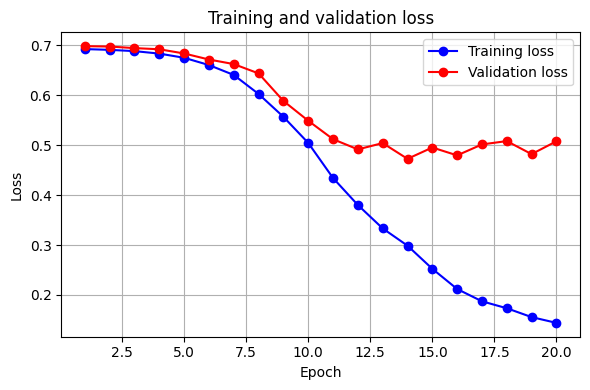

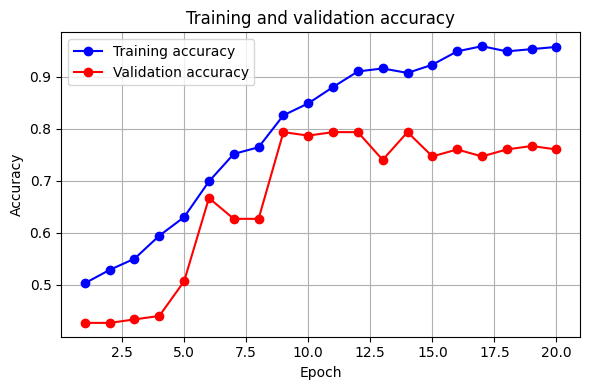

<- Model 20-epochs took 13.06860065460205ms



-> Model 16-batches


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_28 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7791 - loss: 0.4517 
Test accuracy: 0.7733333110809326
Test loss: 0.44847777485847473


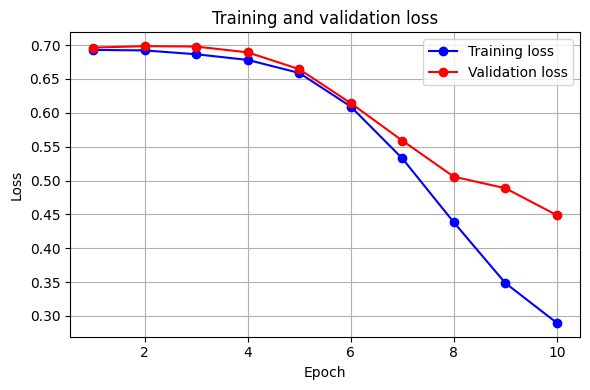

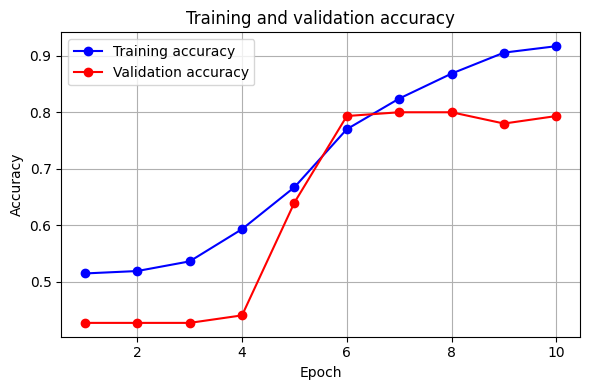

<- Model 16-batches took 12.050774097442627ms



-> Model 64-batches


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_29 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6331 - loss: 0.6452
Test accuracy: 0.6333333253860474
Test loss: 0.6421334743499756


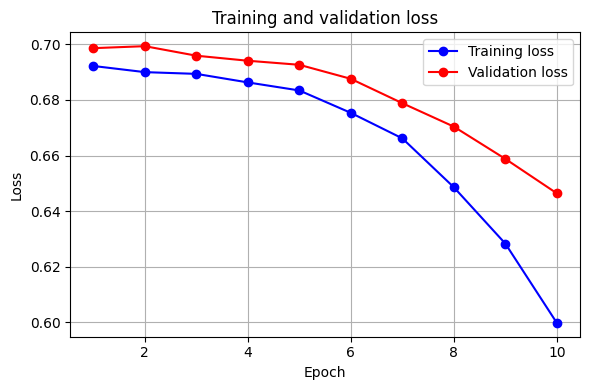

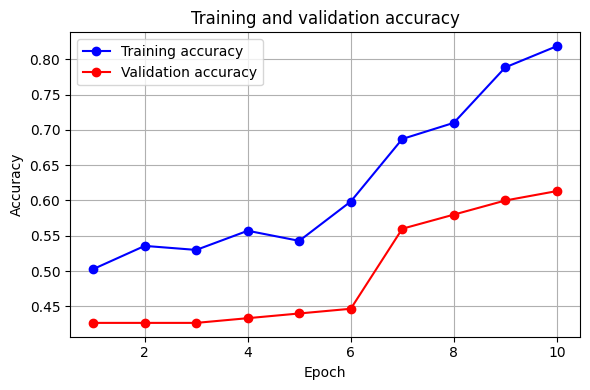

<- Model 64-batches took 6.421314001083374ms



-> Model model_a


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,920,197 (7.32 MB)

 Trainable params: 640,065 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,280,132 (4.88 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5649 - loss: 0.6738
Test accuracy: 0.5866666436195374
Test loss: 0.6713205575942993


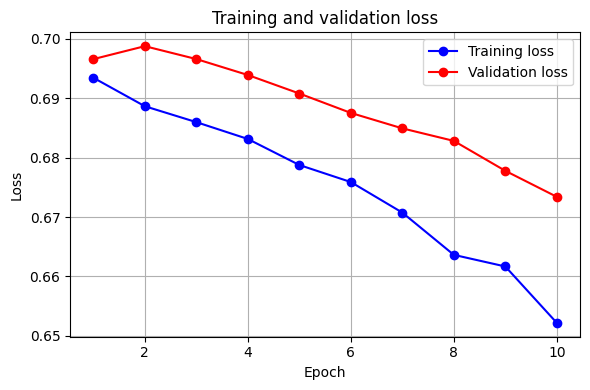

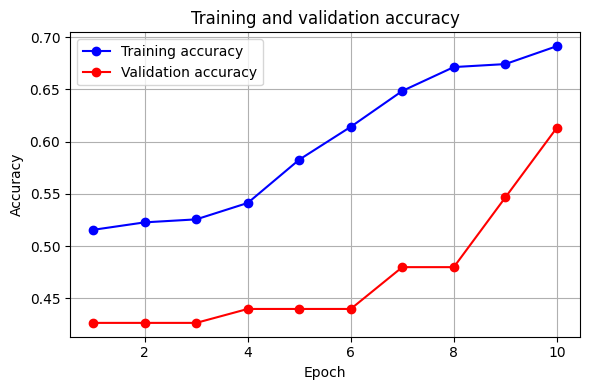

<- Model model_a took 7.178400754928589ms



-> Model model_c


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_31 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,957,829 (7.47 MB)

 Trainable params: 652,609 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,305,220 (4.98 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7962 - loss: 0.4122
Test accuracy: 0.800000011920929
Test loss: 0.42105400562286377


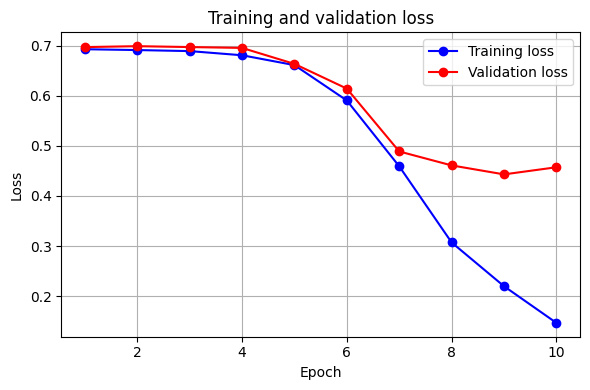

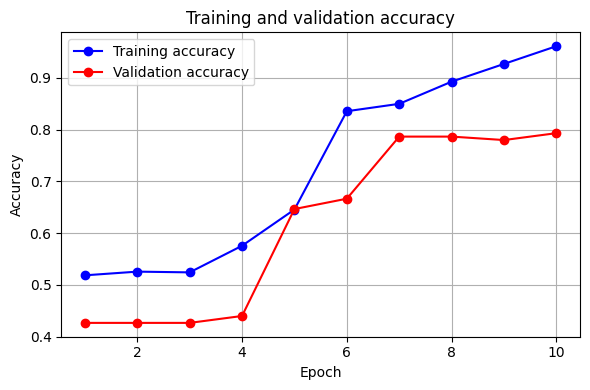

<- Model model_c took 8.069864511489868ms



-> Model model_c


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,969,733 (7.51 MB)

 Trainable params: 656,577 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,313,156 (5.01 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7818 - loss: 0.4304
Test accuracy: 0.7933333516120911
Test loss: 0.4217647314071655


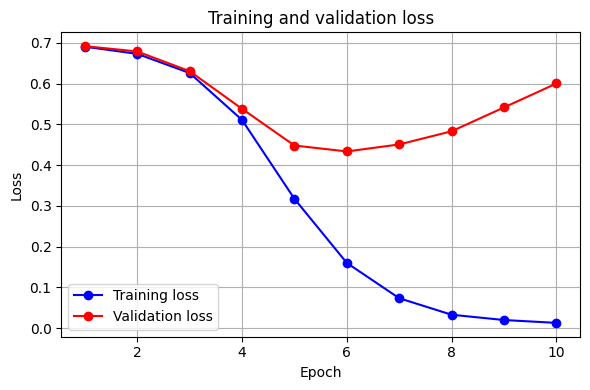

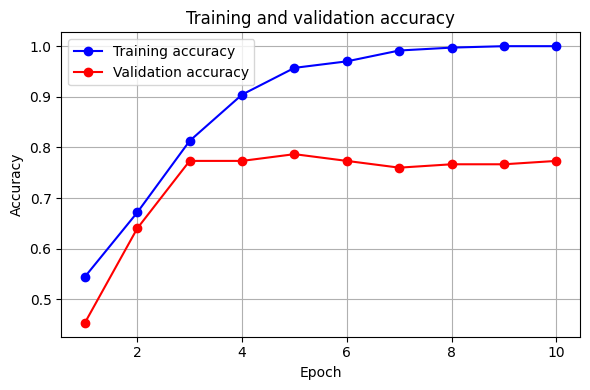

<- Model model_c took 9.204011678695679ms



-> Model tanh


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_33 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7638 - loss: 0.5122
Test accuracy: 0.7599999904632568
Test loss: 0.5038139224052429


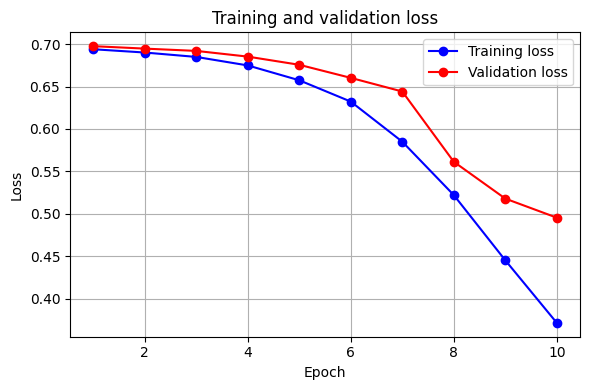

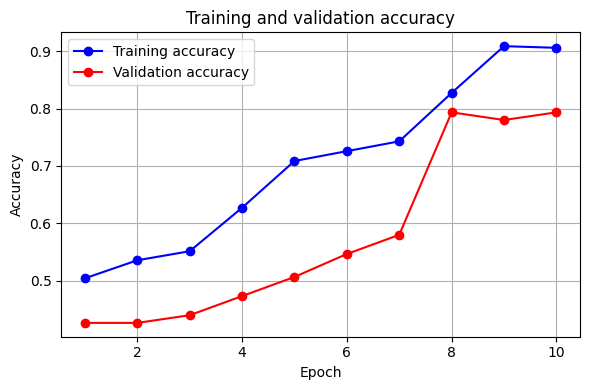

<- Model tanh took 7.77762770652771ms



-> Model hinge


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_34 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4519 - loss: 1.0093
Test accuracy: 0.46000000834465027
Test loss: 0.990735650062561


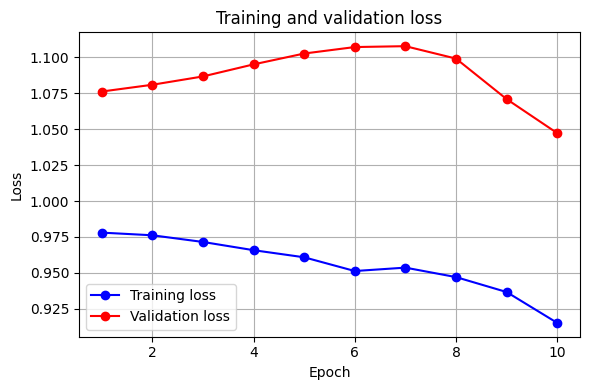

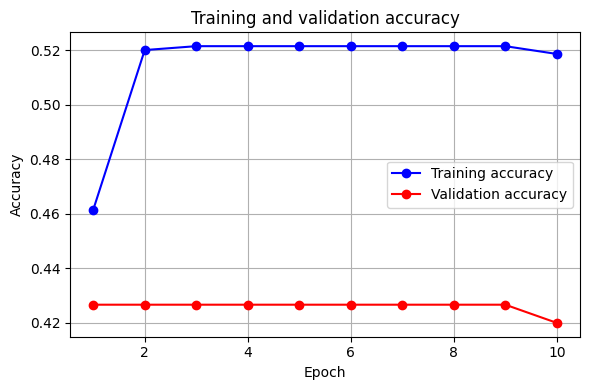

<- Model hinge took 8.76960039138794ms



-> Model sgd


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_35 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,288,452 (4.92 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,227 (2.46 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4607 - loss: 0.6969
Test accuracy: 0.47333332896232605
Test loss: 0.695747435092926


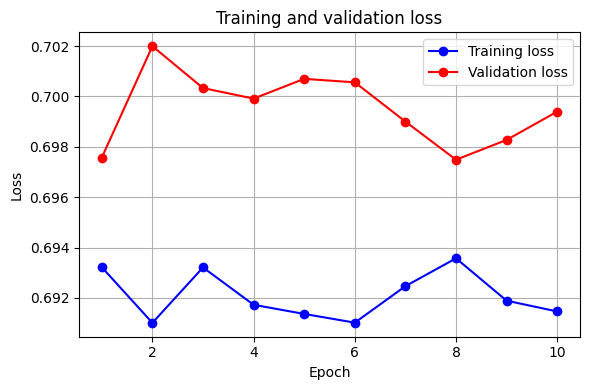

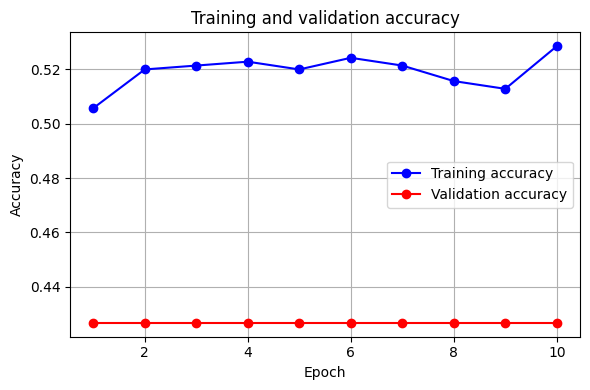

<- Model sgd took 5.37127947807312ms



-> Model sgd


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_36 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,288,452 (4.92 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,227 (2.46 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4607 - loss: 0.6956
Test accuracy: 0.47333332896232605
Test loss: 0.6940887570381165


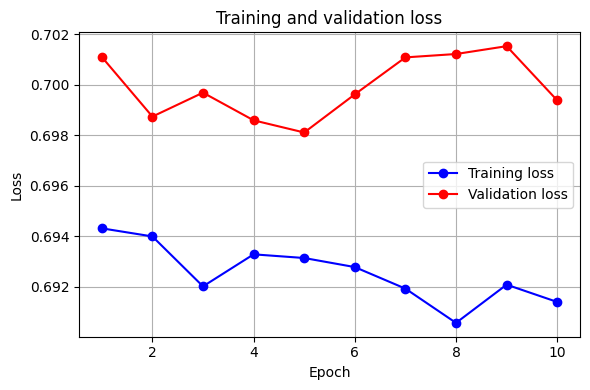

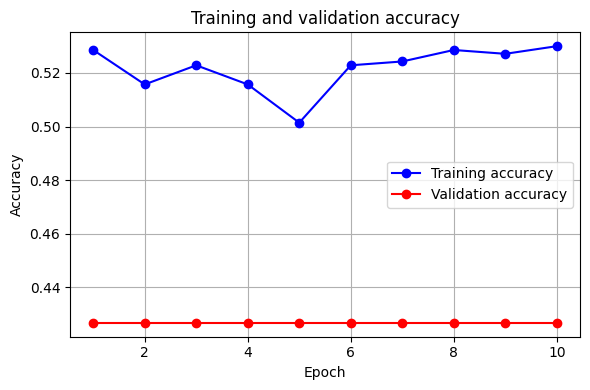

<- Model sgd took 6.776113748550415ms



[{'name': 'default', 'time': 7.760937452316284, 'loss': 0.5596940517425537, 'acc': 0.7599999904632568}, {'name': '5-epochs', 'time': 5.5725202560424805, 'loss': 0.6803271770477295, 'acc': 0.47333332896232605}, {'name': '20-epochs', 'time': 13.06860065460205, 'loss': 0.4386991262435913, 'acc': 0.7599999904632568}, {'name': '16-batches', 'time': 12.050774097442627, 'loss': 0.44847777485847473, 'acc': 0.7733333110809326}, {'name': '64-batches', 'time': 6.421314001083374, 'loss': 0.6421334743499756, 'acc': 0.6333333253860474}, {'name': 'model_a', 'time': 7.178400754928589, 'loss': 0.6713205575942993, 'acc': 0.5866666436195374}, {'name': 'model_c', 'time': 8.069864511489868, 'loss': 0.42105400562286377, 'acc': 0.800000011920929}, {'name': 'model_c', 'time': 9.204011678695679, 'loss': 0.4217647314071655, 'acc': 0.7933333516120911}, {'name': 'tanh', 'time': 7.77762770652771, 'loss': 0.5038139224052429, 'acc': 0.7599999904632568}, {'name': 'hinge', 'tim

In [47]:
run("default")

# Různé počty epoch
## reference: 10 epochs
## default

## zda se model učí už na začátku.
run("5-epochs", epochs=5)

## zda začne přeučení (val_loss začne růst).
run("20-epochs", epochs=20)

# Různé počty batch_size
## reference: 32 batches
## default

## menší batch → více update kroků, často lepší generalizace, ale pomalejší.
run("16-batches", batch_size=16)

## větší batch → rychlejší epochy, ale model se může učit hůř.
run("64-batches", batch_size=64)

# Různý počet vrstev
## Model A (velmi jednoduchý): Dense(1, sigmoid)
run("model_a", extra_layers=[])

## Model B (střední): Dense(64, relu) → Dense(1, sigmoid)
## default

## Model C (složitější): Dense(128, relu) → Dense(64, relu) → Dense(1, sigmoid)
run("model_c", extra_layers=[layers.Dense(64, activation=default_activation), layers.Dense(128, activation=default_activation)])

# Různá konfigurace vrstev
## Konfigurace 1 (baseline): GlobalAveragePooling
## default

## Konfigurace 2 (1D CNN): Conv1D(64, kernel_size=3, activation=relu) → GlobalMaxPooling1D
run("model_c", main_layers=[layers.Conv1D(64, kernel_size=3, activation=default_activation), layers.GlobalMaxPooling1D()])

# Různé aktivační funkce
## Konfigurace 1 (baseline): ReLU
## default

## Konfigurace 2: Tanh
run("tanh", activation="tanh")

# Různé ztrátové funkce
## Konfigurace 1 (baseline): binary_crossentropy
## default

## Konfigurace 2: hinge
run("hinge", loss="hinge")

# Různé optimalizační techniky
## Adam (baseline).
## default

## SGD s momentum
run("sgd", optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))

## RMSprop
run("sgd", optimizer=keras.optimizers.RMSprop(learning_rate=0.001))


print(model_data)

In [ ]:
model_data

In [48]:
results = pd.DataFrame(model_data)
results

,name,time,loss,acc
0,default,7.760937,0.559694,0.760000
1,5-epochs,5.572520,0.680327,0.473333
2,20-epochs,13.068601,0.438699,0.760000
3,16-batches,12.050774,0.448478,0.773333
4,64-batches,6.421314,0.642133,0.633333
5,model_a,7.178401,0.671321,0.586667
6,model_c,8.069865,0.421054,0.800000
7,model_c,9.204012,0.421765,0.793333
8,tanh,7.777628,0.503814,0.760000
9,hinge,8.769600,0.990736,0.460000
